In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import itertools
import plotly.graph_objects as go
from datetime import datetime,date
!pip install missingno
import missingno as msno
#from datetime import date
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler

In [121]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 25)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

Load Data

In [123]:
df = pd.read_csv("powerconsumption.csv")
df.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,2017-01-01 00:00:00,6.559,73.800,0.083,0.051,0.119,34055.696,16128.875,20240.964
1,2017-01-01 00:10:00,6.414,74.500,0.083,0.070,0.085,29814.684,19375.076,20131.084
2,2017-01-01 00:20:00,6.313,74.500,0.080,0.062,0.100,29128.101,19006.687,19668.434
3,2017-01-01 00:30:00,6.121,75.000,0.083,0.091,0.096,28228.861,18361.094,18899.277
4,2017-01-01 00:40:00,5.921,75.700,0.081,0.048,0.085,27335.696,17872.340,18442.410


In [29]:
df["Temperature"].min()

3.247

In [31]:
def detailed_check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)

    print("\n##################### Info #####################")
    print(dataframe.info(memory_usage='deep'))

    print("\n##################### Types #####################")
    print(dataframe.dtypes)

    print("\n##################### Missing Values #####################")
    missing_values = dataframe.isnull().sum()
    print(missing_values[missing_values > 0])

    print("\n##################### Unique Values #####################")
    for column in dataframe.columns:
        print(f"{column} has {dataframe[column].nunique()} unique values")

detailed_check_df(df)

##################### Shape #####################
(52416, 9)

##################### Info #####################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Datetime                52416 non-null  object 
 1   Temperature             52416 non-null  float64
 2   Humidity                52416 non-null  float64
 3   WindSpeed               52416 non-null  float64
 4   GeneralDiffuseFlows     52416 non-null  float64
 5   DiffuseFlows            52416 non-null  float64
 6   PowerConsumption_Zone1  52416 non-null  float64
 7   PowerConsumption_Zone2  52416 non-null  float64
 8   PowerConsumption_Zone3  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 7.0 MB
None

##################### Types #####################
Datetime                   object
Temperature               float64
Humidity               

In [33]:
# Convert the 'Datetime' column to datetime format
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Create a new 'date' column by extracting only the date part
df['date'] = df['Datetime'].dt.date

# Display the result
print(df)

                 Datetime  Temperature  Humidity  WindSpeed  \
0     2017-01-01 00:00:00        6.559    73.800      0.083   
1     2017-01-01 00:10:00        6.414    74.500      0.083   
2     2017-01-01 00:20:00        6.313    74.500      0.080   
3     2017-01-01 00:30:00        6.121    75.000      0.083   
4     2017-01-01 00:40:00        5.921    75.700      0.081   
...                   ...          ...       ...        ...   
52411 2017-12-30 23:10:00        7.010    72.400      0.080   
52412 2017-12-30 23:20:00        6.947    72.600      0.082   
52413 2017-12-30 23:30:00        6.900    72.800      0.086   
52414 2017-12-30 23:40:00        6.758    73.000      0.080   
52415 2017-12-30 23:50:00        6.580    74.100      0.081   

       GeneralDiffuseFlows  DiffuseFlows  PowerConsumption_Zone1  \
0                    0.051         0.119               34055.696   
1                    0.070         0.085               29814.684   
2                    0.062         0.10

Creating New Features

In [40]:
# Assuming you have already read your dataframe 'df'

# Convert the Datetime column to datetime format
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Create new columns
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day
df['Hour'] = df['Datetime'].dt.hour

# Define time of day categories
def categorize_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'

df['TimeOfDay'] = df['Hour'].apply(categorize_time_of_day)

# Add day of the week (0 = Monday, 6 = Sunday)
df['Weekday'] = df['Datetime'].dt.weekday

# Add a column to indicate if it's a weekend
df['IsWeekend'] = df['Weekday'].apply(lambda x: 1 if x >= 5 else 0)

# Define the seasons
def categorize_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(categorize_season)

# Let's set the data types to numeric
df['Year'] = df['Year'].astype(int)
df['Weekday'] = df['Weekday'].astype(int)
df['IsWeekend'] = df['IsWeekend'].astype(int)

df.tail()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,date,Year,Month,Day,Hour,TimeOfDay,Weekday,IsWeekend,Season
52411,2017-12-30 23:10:00,7.010,72.400,0.080,0.040,0.096,31160.456,26857.318,14780.312,2017-12-30,2017,12,30,23,Evening,5,1,Winter
52412,2017-12-30 23:20:00,6.947,72.600,0.082,0.051,0.093,30430.418,26124.578,14428.812,2017-12-30,2017,12,30,23,Evening,5,1,Winter
52413,2017-12-30 23:30:00,6.900,72.800,0.086,0.084,0.074,29590.875,25277.693,13806.483,2017-12-30,2017,12,30,23,Evening,5,1,Winter
52414,2017-12-30 23:40:00,6.758,73.000,0.080,0.066,0.089,28958.175,24692.237,13512.605,2017-12-30,2017,12,30,23,Evening,5,1,Winter
52415,2017-12-30 23:50:00,6.580,74.100,0.081,0.062,0.111,28349.810,24055.232,13345.498,2017-12-30,2017,12,30,23,Evening,5,1,Winter


In [42]:
df.drop(columns=['Datetime'], inplace=True)
df.drop(columns=['date'], inplace=True)

Checking the Categorical and Numeric Columns

In [44]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    # Categorical columns
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtype == "O"]
    
    # Numeric columns:
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    
    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    
    return cat_cols, num_cols

cat_cols, num_cols = grab_col_names(df)

Observations: 52416
Variables: 16
cat_cols: 2
num_cols: 14


In [46]:
cat_cols

['TimeOfDay', 'Season']

In [48]:
df[cat_cols]

,TimeOfDay,Season
0,Night,Winter
1,Night,Winter
2,Night,Winter
3,Night,Winter
4,Night,Winter
...,...,...
52411,Evening,Winter
52412,Evening,Winter
52413,Evening,Winter
52414,Evening,Winter


Encoding-One-Hot Encoding

In [50]:
# Convert categorical variables to numerical values using One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['TimeOfDay', 'Season'])

# Convert the columns resulting from One-Hot Encoding to integer values
df_encoded = df_encoded.astype(int)

# Display the results
df_encoded.head(6)

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,Year,Month,Day,Hour,Weekday,IsWeekend,TimeOfDay_Afternoon,TimeOfDay_Evening,TimeOfDay_Morning,TimeOfDay_Night,Season_Autumn,Season_Spring,Season_Summer,Season_Winter
0,6,73,0,0,0,34055,16128,20240,2017,1,1,0,6,1,0,0,0,1,0,0,0,1
1,6,74,0,0,0,29814,19375,20131,2017,1,1,0,6,1,0,0,0,1,0,0,0,1
2,6,74,0,0,0,29128,19006,19668,2017,1,1,0,6,1,0,0,0,1,0,0,0,1
3,6,75,0,0,0,28228,18361,18899,2017,1,1,0,6,1,0,0,0,1,0,0,0,1
4,5,75,0,0,0,27335,17872,18442,2017,1,1,0,6,1,0,0,0,1,0,0,0,1
5,5,76,0,0,0,26624,17416,18130,2017,1,1,0,6,1,0,0,0,1,0,0,0,1


In [54]:
# Calculate min and sum values by grouping
aggregation_functions = {
    'Temperature': ['mean'],
    'Humidity': ['mean'],
    'WindSpeed': ['mean'],
    'GeneralDiffuseFlows': ['mean'],
    'DiffuseFlows': ['mean'],
    'PowerConsumption_Zone1': ['sum'],
    'PowerConsumption_Zone2': ['sum'],
    'PowerConsumption_Zone3': ['sum'],
    #'IsHoliday': ['first'],#
    #'Weekday': ['first'],#
    #'IsWeekend': ['first'],#
    'TimeOfDay_Afternoon': ['first'],
    'TimeOfDay_Evening': ['first'],
    'TimeOfDay_Morning': ['first'],
    'TimeOfDay_Night': ['first'],
    'Season_Autumn': ['first'],
    'Season_Spring': ['first'],
    'Season_Summer': ['first'],
    'Season_Winter': ['first']
}

df_grouped = df_encoded.groupby(['Year', 'Month', 'Day', 'Hour']).agg(aggregation_functions)

# Correct column names
df_grouped.columns = ['_'.join(col) if isinstance(col, tuple) else col for col in df_grouped.columns]
df_grouped = df_grouped.reset_index()

# Display the result
df_grouped.head(25)


,Year,Month,Day,Hour,Temperature_mean,Humidity_mean,WindSpeed_mean,GeneralDiffuseFlows_mean,DiffuseFlows_mean,PowerConsumption_Zone1_sum,PowerConsumption_Zone2_sum,PowerConsumption_Zone3_sum,TimeOfDay_Afternoon_first,TimeOfDay_Evening_first,TimeOfDay_Morning_first,TimeOfDay_Night_first,Season_Autumn_first,Season_Spring_first,Season_Summer_first,Season_Winter_first
0,2017,1,1,0,5.667,74.500,0.000,0.000,0.000,175184,108158,115510,0,0,0,1,0,0,0,1
1,2017,1,1,1,5.000,77.167,0.000,0.000,0.000,147940,96468,102256,0,0,0,1,0,0,0,1
2,2017,1,1,2,4.500,78.333,0.000,0.000,0.000,132496,85981,94054,0,0,0,1,0,0,0,1
3,2017,1,1,3,4.667,76.500,0.000,0.000,0.000,124863,79314,89301,0,0,0,1,0,0,0,1
4,2017,1,1,4,4.667,73.667,0.000,0.000,0.000,122853,77527,85901,0,0,0,1,0,0,0,1
5,2017,1,1,5,4.167,74.667,0.000,0.000,0.000,124838,78416,86367,0,0,0,1,0,0,0,1
6,2017,1,1,6,4.000,75.333,0.000,0.000,0.000,129889,81575,87079,0,0,1,0,0,0,0,1
7,2017,1,1,7,4.000,73.167,0.000,0.000,0.000,111241,68696,69313,0,0,1,0,0,0,0,1
8,2017,1,1,8,4.000,73.167,0.000,13.167,6.000,117627,70429,67139,0,0,1,0,0,0,0,1
9,2017,1,1,9,4.000,73.500,0.000,144.333,24.833,137430,82884,78155,0,0,1,0,0,0,0,1


In [56]:
df_grouped.dtypes

Year                            int32
Month                           int32
Day                             int32
Hour                            int32
Temperature_mean              float64
Humidity_mean                 float64
WindSpeed_mean                float64
GeneralDiffuseFlows_mean      float64
DiffuseFlows_mean             float64
PowerConsumption_Zone1_sum      int32
PowerConsumption_Zone2_sum      int32
PowerConsumption_Zone3_sum      int32
TimeOfDay_Afternoon_first       int32
TimeOfDay_Evening_first         int32
TimeOfDay_Morning_first         int32
TimeOfDay_Night_first           int32
Season_Autumn_first             int32
Season_Spring_first             int32
Season_Summer_first             int32
Season_Winter_first             int32
dtype: object

In [58]:
# Columns to create lag features
columns_to_lag = [
    'Temperature_mean', 'Humidity_mean', 'WindSpeed_mean', 'GeneralDiffuseFlows_mean', 
    'DiffuseFlows_mean', 'PowerConsumption_Zone1_sum', 'PowerConsumption_Zone2_sum', 
    'PowerConsumption_Zone3_sum'
]

# Lag values (24, 48, 72 hours)
lags = [4, 8, 12, 24, 48]

# Create lag features
df_lagged = df_grouped.copy()

for col in columns_to_lag:
    for lag in lags:
        df_lagged[f'{col}_lag{lag}'] = df_grouped[col].shift(lag)

# Remove rows with NaN values due to lagging
df_lagged = df_lagged.dropna()

# Display the result
df_lagged.head()


,Year,Month,Day,Hour,Temperature_mean,Humidity_mean,WindSpeed_mean,GeneralDiffuseFlows_mean,DiffuseFlows_mean,PowerConsumption_Zone1_sum,PowerConsumption_Zone2_sum,PowerConsumption_Zone3_sum,TimeOfDay_Afternoon_first,TimeOfDay_Evening_first,TimeOfDay_Morning_first,TimeOfDay_Night_first,Season_Autumn_first,Season_Spring_first,Season_Summer_first,Season_Winter_first,Temperature_mean_lag4,Temperature_mean_lag8,Temperature_mean_lag12,Temperature_mean_lag24,Temperature_mean_lag48,Humidity_mean_lag4,Humidity_mean_lag8,Humidity_mean_lag12,Humidity_mean_lag24,Humidity_mean_lag48,WindSpeed_mean_lag4,WindSpeed_mean_lag8,WindSpeed_mean_lag12,WindSpeed_mean_lag24,WindSpeed_mean_lag48,GeneralDiffuseFlows_mean_lag4,GeneralDiffuseFlows_mean_lag8,GeneralDiffuseFlows_mean_lag12,GeneralDiffuseFlows_mean_lag24,GeneralDiffuseFlows_mean_lag48,DiffuseFlows_mean_lag4,DiffuseFlows_mean_lag8,DiffuseFlows_mean_lag12,DiffuseFlows_mean_lag24,DiffuseFlows_mean_lag48,PowerConsumption_Zone1_sum_lag4,PowerConsumption_Zone1_sum_lag8,PowerConsumption_Zone1_sum_lag12,PowerConsumption_Zone1_sum_lag24,PowerConsumption_Zone1_sum_lag48,PowerConsumption_Zone2_sum_lag4,PowerConsumption_Zone2_sum_lag8,PowerConsumption_Zone2_sum_lag12,PowerConsumption_Zone2_sum_lag24,PowerConsumption_Zone2_sum_lag48,PowerConsumption_Zone3_sum_lag4,PowerConsumption_Zone3_sum_lag8,PowerConsumption_Zone3_sum_lag12,PowerConsumption_Zone3_sum_lag24,PowerConsumption_Zone3_sum_lag48
48,2017,1,3,0,11.500,75.167,0.000,0.000,0.000,151615,104214,102191,0,0,0,1,0,0,0,1,13.000,15.000,15.000,10.167,5.667,68.167,60.167,57.500,77.667,74.500,0.000,0.000,0.000,0.000,0.000,0.000,225.167,470.667,0.000,0.000,0.000,225.000,42.833,0.000,0.000,246577.000,179978.000,177486.000,151817.000,175184.000,160691.000,123845.000,119701.000,102044.000,108158.000,153851.000,98079.000,109196.000,101308.000,115510.000
49,2017,1,3,1,11.667,72.333,0.000,0.000,0.000,135819,91300,91139,0,0,0,1,0,0,0,1,12.667,14.500,15.000,10.333,5.000,66.333,61.000,59.000,78.333,77.167,0.000,0.000,0.000,0.000,0.000,0.000,86.000,483.667,0.000,0.000,0.000,107.333,43.500,0.000,0.000,236765.000,222134.000,176911.000,135072.000,147940.000,155247.000,146856.000,117428.000,89461.000,96468.000,150012.000,134687.000,113675.000,90473.000,102256.000
50,2017,1,3,2,11.500,73.333,0.000,0.000,0.000,128224,84449,85385,0,0,0,1,0,0,0,1,12.000,13.833,15.000,10.667,4.500,68.000,65.167,55.500,76.500,78.333,0.000,0.000,0.000,0.000,0.000,0.000,3.333,444.167,0.000,0.000,0.000,3.333,41.667,0.000,0.000,214981.000,250484.000,171666.000,125673.000,132496.000,141291.000,161923.000,120967.000,83013.000,85981.000,137035.000,153041.000,109646.000,84991.000,94054.000
51,2017,1,3,3,11.667,73.333,0.000,0.000,0.000,123345,81973,82251,0,0,0,1,0,0,0,1,12.000,13.000,15.000,10.000,4.667,71.167,69.000,56.833,78.667,76.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,352.500,0.000,0.000,0.000,0.000,64.000,0.000,0.000,180671.000,248990.000,173824.000,120580.000,124863.000,122237.000,161143.000,128010.000,80795.000,79314.000,119644.000,153268.000,99063.000,82765.000,89301.000
52,2017,1,3,4,10.833,76.000,0.000,0.000,0.000,120695,81765,81545,0,0,0,1,0,0,0,1,11.500,13.000,15.000,9.833,4.667,75.167,68.167,60.167,81.333,73.667,0.000,0.000,0.000,0.000,0.000,0.000,0.000,225.167,0.000,0.000,0.000,0.000,225.000,0.000,0.000,151615.000,246577.000,179978.000,120397.000,122853.000,104214.000,160691.000,123845.000,79489.000,77527.000,102191.000,153851.000,98079.000,81625.000,85901.000


Exploratory Data Analysis (EDA)

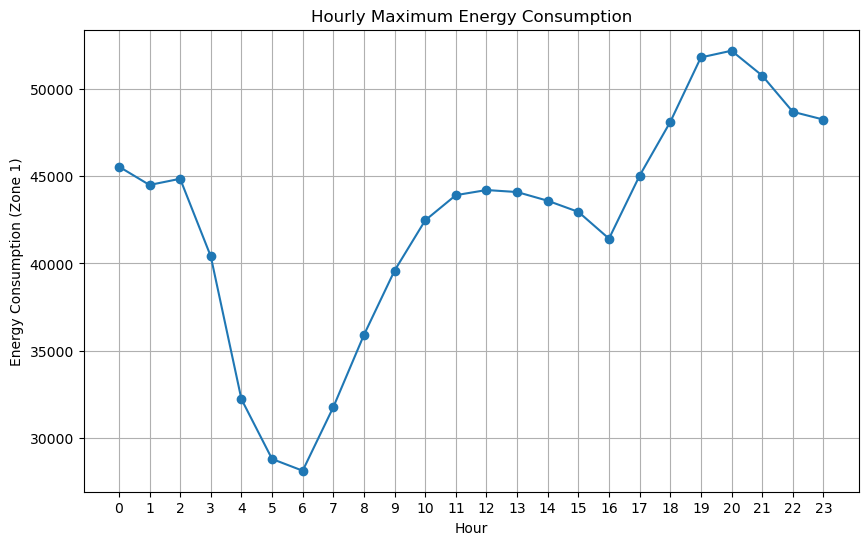

In [60]:
# Calculate the hourly maximum energy consumption
hourly_max = df.groupby('Hour')['PowerConsumption_Zone1'].max().reset_index()

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(hourly_max['Hour'], hourly_max['PowerConsumption_Zone1'], marker='o')
plt.title('Hourly Maximum Energy Consumption')
plt.xlabel('Hour')
plt.ylabel('Energy Consumption (Zone 1)')
plt.grid(True)
plt.xticks(range(0, 24))
plt.show()

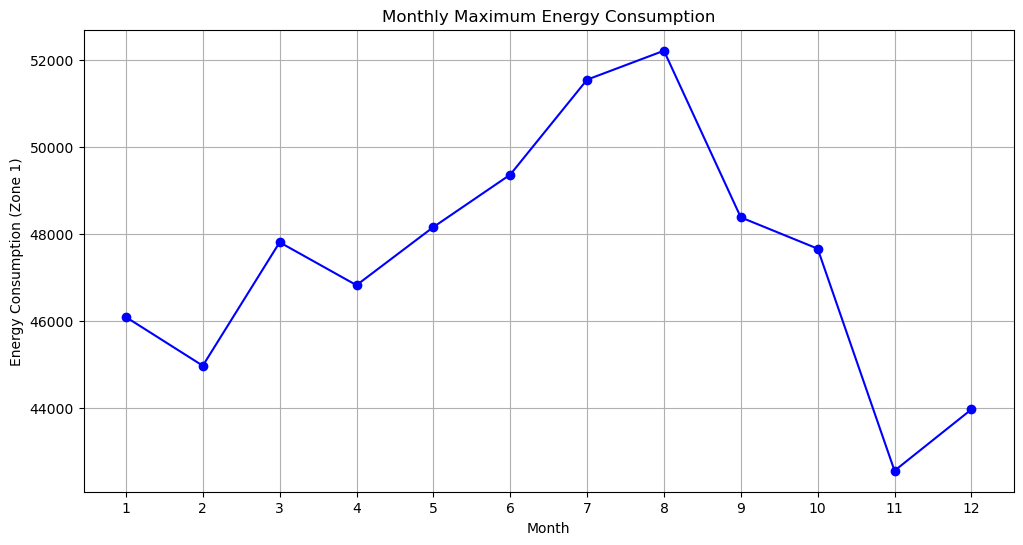

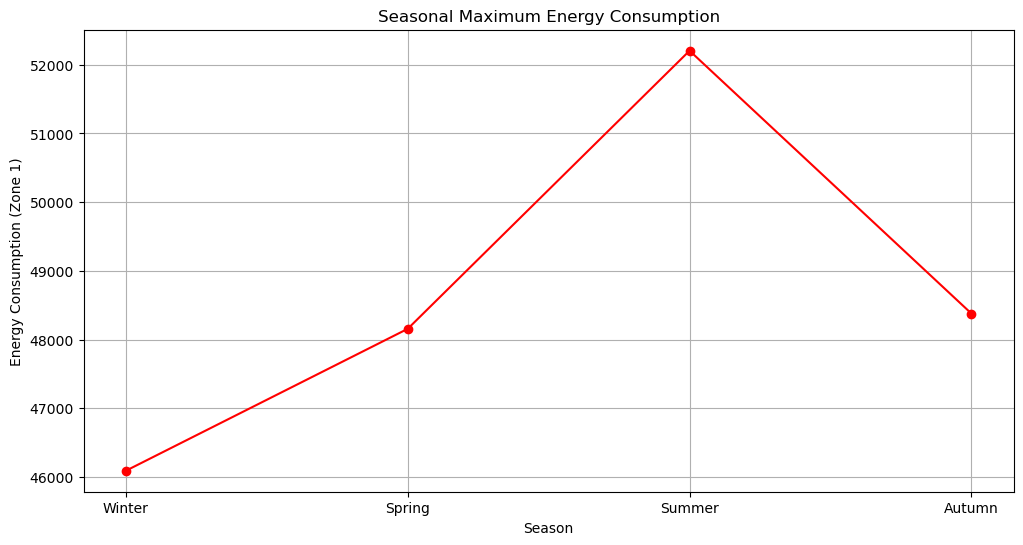

In [62]:
# Monthly maximum energy consumption
monthly_max = df.groupby('Month')['PowerConsumption_Zone1'].max().reset_index()

# Seasonal maximum energy consumption
seasonal_max = df.groupby('Season')['PowerConsumption_Zone1'].max().reset_index()

# To display seasons in order
seasonal_max['Season'] = pd.Categorical(seasonal_max['Season'], categories=['Winter', 'Spring', 'Summer', 'Autumn'], ordered=True)
seasonal_max = seasonal_max.sort_values('Season')

# Plot for monthly maximum energy consumption
plt.figure(figsize=(12, 6))
plt.plot(monthly_max['Month'], monthly_max['PowerConsumption_Zone1'], marker='o', linestyle='-', color='b')
plt.title('Monthly Maximum Energy Consumption')
plt.xlabel('Month')
plt.ylabel('Energy Consumption (Zone 1)')
plt.grid(True)
plt.xticks(range(1, 13))
plt.show()

# Plot for seasonal maximum energy consumption
plt.figure(figsize=(12, 6))
plt.plot(seasonal_max['Season'], seasonal_max['PowerConsumption_Zone1'], marker='o', linestyle='-', color='r')
plt.title('Seasonal Maximum Energy Consumption')
plt.xlabel('Season')
plt.ylabel('Energy Consumption (Zone 1)')
plt.grid(True)
plt.show()

In [64]:
df['Month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [66]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# List of columns to scale
cols_to_scale = [
    "Temperature_mean", "Humidity_mean", "WindSpeed_mean", 
    "GeneralDiffuseFlows_mean", "DiffuseFlows_mean", "PowerConsumption_Zone1_sum", "PowerConsumption_Zone2_sum", "PowerConsumption_Zone3_sum", 
    "Temperature_mean_lag4", "Temperature_mean_lag8", "Temperature_mean_lag12", "Temperature_mean_lag24", "Temperature_mean_lag48", 
    "Humidity_mean_lag4", "Humidity_mean_lag8", "Humidity_mean_lag12", "Humidity_mean_lag24", "Humidity_mean_lag48",
    "WindSpeed_mean_lag4", "WindSpeed_mean_lag8", "WindSpeed_mean_lag12", "WindSpeed_mean_lag24", "WindSpeed_mean_lag48", 
    "GeneralDiffuseFlows_mean_lag4", "GeneralDiffuseFlows_mean_lag8", "GeneralDiffuseFlows_mean_lag12", "GeneralDiffuseFlows_mean_lag24", "GeneralDiffuseFlows_mean_lag48",
    "DiffuseFlows_mean_lag4", "DiffuseFlows_mean_lag8", "DiffuseFlows_mean_lag12", "DiffuseFlows_mean_lag24", "DiffuseFlows_mean_lag48", 
    "PowerConsumption_Zone1_sum_lag4", "PowerConsumption_Zone1_sum_lag8", "PowerConsumption_Zone1_sum_lag12", "PowerConsumption_Zone1_sum_lag24", "PowerConsumption_Zone1_sum_lag48",
    "PowerConsumption_Zone2_sum_lag4", "PowerConsumption_Zone2_sum_lag8", "PowerConsumption_Zone2_sum_lag12", "PowerConsumption_Zone2_sum_lag24", "PowerConsumption_Zone2_sum_lag48", 
    "PowerConsumption_Zone3_sum_lag4", "PowerConsumption_Zone3_sum_lag8", "PowerConsumption_Zone3_sum_lag12", "PowerConsumption_Zone3_sum_lag24",  "PowerConsumption_Zone3_sum_lag48"
]


# MinMaxScaler
scaler = MinMaxScaler()
df_lagged[cols_to_scale] = scaler.fit_transform(df_lagged[cols_to_scale])

# Check the first few rows
print(df_lagged.head())

    Year  Month  Day  Hour  Temperature_mean  Humidity_mean  WindSpeed_mean  \
48  2017      1    3     0             0.235          0.770           0.000   
49  2017      1    3     1             0.240          0.735           0.000   
50  2017      1    3     2             0.235          0.747           0.000   
51  2017      1    3     3             0.240          0.747           0.000   
52  2017      1    3     4             0.217          0.780           0.000   

    GeneralDiffuseFlows_mean  DiffuseFlows_mean  PowerConsumption_Zone1_sum  \
48                     0.000              0.000                       0.292   
49                     0.000              0.000                       0.221   
50                     0.000              0.000                       0.188   
51                     0.000              0.000                       0.166   
52                     0.000              0.000                       0.154   

    PowerConsumption_Zone2_sum  PowerConsumption_Z

K-Means

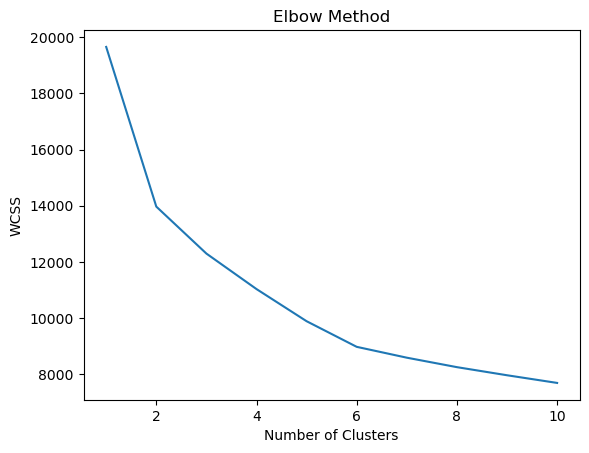

In [117]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# Determine the optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=20, random_state=np.random.randint(0, 100))
    kmeans.fit(df_lagged[cols_to_scale])
    wcss.append(kmeans.inertia_)

# Plot the results of the Elbow Method
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [81]:
# Apply the K-means algorithm
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=0)
df_lagged['Cluster'] = kmeans.fit_predict(df_lagged[cols_to_scale])

# Add the clusters to the original DataFrame
df_lagged['Cluster'] = kmeans.labels_

            Year  Month    Day   Hour  Temperature_mean  Humidity_mean  \
Cluster                                                                  
0       2017.000  7.291 17.510 11.727             0.531          0.648   
1       2017.000  6.072 14.666 15.659             0.412          0.625   
2       2017.000  6.126 14.781  6.459             0.304          0.781   

         WindSpeed_mean  GeneralDiffuseFlows_mean  DiffuseFlows_mean  \
Cluster                                                                
0                 0.692                     0.232              0.083   
1                 0.044                     0.292              0.150   
2                 0.037                     0.026              0.021   

         PowerConsumption_Zone1_sum  PowerConsumption_Zone2_sum  \
Cluster                                                           
0                             0.531                       0.493   
1                             0.578                       0.536   


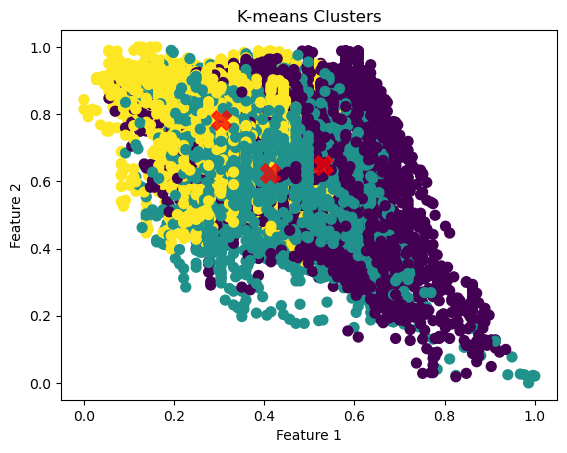

In [73]:
# Calculate the mean values for each cluster
cluster_means = df_lagged.groupby('Cluster').mean()
print(cluster_means)

# Visualize the clusters
plt.scatter(df_lagged[cols_to_scale].iloc[:, 0], df_lagged[cols_to_scale].iloc[:, 1], c=df_lagged['Cluster'], s=50, cmap='viridis')

# Also visualize the cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.title('K-means Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

Train Random Forest Models

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# Independent variables
X = df_lagged.drop(['PowerConsumption_Zone1_sum', 'PowerConsumption_Zone2_sum', 'PowerConsumption_Zone3_sum'], axis=1)

# Target variables
y1 = df_lagged['PowerConsumption_Zone1_sum']
y2 = df_lagged['PowerConsumption_Zone2_sum']
y3 = df_lagged['PowerConsumption_Zone3_sum']

# Split data into training and test sets
X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=0)
_, _, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=0)
_, _, y3_train, y3_test = train_test_split(X, y3, test_size=0.2, random_state=0)

# Create and train models
model1 = RandomForestRegressor(random_state=0)
model2 = RandomForestRegressor(random_state=0)
model3 = RandomForestRegressor(random_state=0)

model1.fit(X_train, y1_train)
model2.fit(X_train, y2_train)
model3.fit(X_train, y3_train)

# Make predictions
y1_pred = model1.predict(X_test)
y2_pred = model2.predict(X_test)
y3_pred = model3.predict(X_test)

# Evaluate results
print("Zone 1 MSE:", np.mean((y1_pred - y1_test)**2))
print("Zone 2 MSE:", np.mean((y2_pred - y2_test)**2))
print("Zone 3 MSE:", np.mean((y3_pred - y3_test)**2))

print("Zone 1 R^2:", r2_score(y1_test, y1_pred))
print("Zone 2 R^2:", r2_score(y2_test, y2_pred))
print("Zone 3 R^2:", r2_score(y3_test, y3_pred))

print("Zone 1 MAE:", mean_absolute_error(y1_test, y1_pred))
print("Zone 2 MAE:", mean_absolute_error(y2_test, y2_pred))
print("Zone 3 MAE:", mean_absolute_error(y3_test, y3_pred))

def adjusted_r2_score(y_true, y_pred, n, p):
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    return adj_r2

# Get the number of test and predicted values
n1 = len(y1_test)
n2 = len(y2_test)
n3 = len(y3_test)

# Specify the number of features
p = X_train.shape[1]

# Adjusted R² for Zone 1
adj_r2_zone1 = adjusted_r2_score(y1_test, y1_pred, n1, p)
print("Zone 1 Adjusted R^2:", adj_r2_zone1)

# Adjusted R² for Zone 2
adj_r2_zone2 = adjusted_r2_score(y2_test, y2_pred, n2, p)
print("Zone 2 Adjusted R^2:", adj_r2_zone2)

# Adjusted R² for Zone 3
adj_r2_zone3 = adjusted_r2_score(y3_test, y3_pred, n3, p)
print("Zone 3 Adjusted R^2:", adj_r2_zone3)

Zone 1 MSE: 0.00146532006856132
Zone 2 MSE: 0.0019825074956275556
Zone 3 MSE: 0.00048323081899554886
Zone 1 R^2: 0.9592518942269096
Zone 2 R^2: 0.9420155883109593
Zone 3 R^2: 0.9818113020595115
Zone 1 MAE: 0.025172012872385893
Zone 2 MAE: 0.03001903779291473
Zone 3 MAE: 0.014070707457613497
Zone 1 Adjusted R^2: 0.957844276517059
Zone 2 Adjusted R^2: 0.9400125532436786
Zone 3 Adjusted R^2: 0.9811829849180295


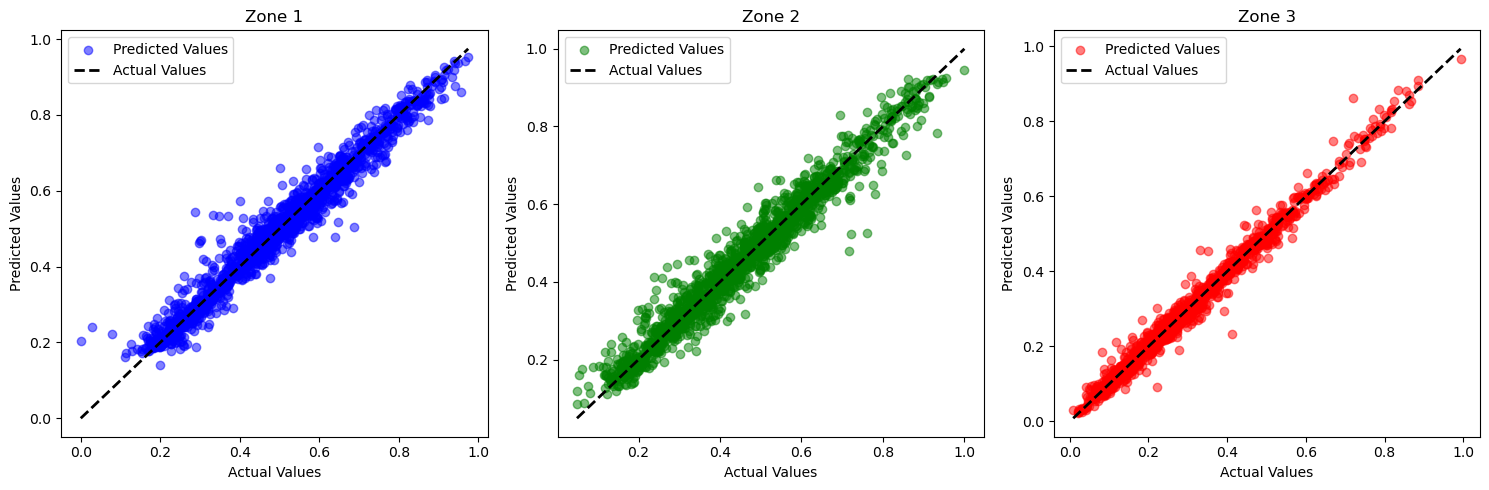

In [113]:
#import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Zone 1
plt.subplot(1, 3, 1)
plt.scatter(y1_test, y1_pred, alpha=0.5, label='Predicted Values', color='blue')
plt.plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], 'k--', lw=2, label='Actual Values')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Zone 1")
plt.legend()

# Zone 2
plt.subplot(1, 3, 2)
plt.scatter(y2_test, y2_pred, alpha=0.5, label='Predicted Values', color='green')
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'k--', lw=2, label='Actual Values')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Zone 2")
plt.legend()

# Zone 3
plt.subplot(1, 3, 3)
plt.scatter(y3_test, y3_pred, alpha=0.5, label='Predicted Values', color='red')
plt.plot([y3_test.min(), y3_test.max()], [y3_test.min(), y3_test.max()], 'k--', lw=2, label='Actual Values')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Zone 3")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
Train xgboost Models

In [93]:
!pip install xgboost
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# Independent variables
X = df_lagged.drop(['PowerConsumption_Zone1_sum', 'PowerConsumption_Zone2_sum', 'PowerConsumption_Zone3_sum'], axis=1)

# Target variables
y1 = df_lagged['PowerConsumption_Zone1_sum']
y2 = df_lagged['PowerConsumption_Zone2_sum']
y3 = df_lagged['PowerConsumption_Zone3_sum']

# Split data into training and test sets
X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=0)
_, _, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=0)
_, _, y3_train, y3_test = train_test_split(X, y3, test_size=0.2, random_state=0)

# Create and train models
model1 = xgb.XGBRegressor(random_state=0)
model2 = xgb.XGBRegressor(random_state=0)
model3 = xgb.XGBRegressor(random_state=0)

model1.fit(X_train, y1_train)
model2.fit(X_train, y2_train)
model3.fit(X_train, y3_train)

# Make predictions
y1_pred = model1.predict(X_test)
y2_pred = model2.predict(X_test)
y3_pred = model3.predict(X_test)

# Evaluate results
print("Zone 1 MSE:", np.mean((y1_pred - y1_test)**2))
print("Zone 2 MSE:", np.mean((y2_pred - y2_test)**2))
print("Zone 3 MSE:", np.mean((y3_pred - y3_test)**2))

print("Zone 1 R^2:", r2_score(y1_test, y1_pred))
print("Zone 2 R^2:", r2_score(y2_test, y2_pred))
print("Zone 3 R^2:", r2_score(y3_test, y3_pred))

print("Zone 1 MAE:", mean_absolute_error(y1_test, y1_pred))
print("Zone 2 MAE:", mean_absolute_error(y2_test, y2_pred))
print("Zone 3 MAE:", mean_absolute_error(y3_test, y3_pred))

def adjusted_r2_score(y_true, y_pred, n, p):
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    return adj_r2

# Get the number of test and predicted values
n1 = len(y1_test)
n2 = len(y2_test)
n3 = len(y3_test)

# Specify the number of features
p = X.shape[1]  # Updated to use the number of independent variables

# Adjusted R² for Zone 1
adj_r2_zone1 = adjusted_r2_score(y1_test, y1_pred, n1, p)
print("Zone 1 Adjusted R^2:", adj_r2_zone1)

# Adjusted R² for Zone 2
adj_r2_zone2 = adjusted_r2_score(y2_test, y2_pred, n2, p)
print("Zone 2 Adjusted R^2:", adj_r2_zone2)

# Adjusted R² for Zone 3
adj_r2_zone3 = adjusted_r2_score(y3_test, y3_pred, n3, p)
print("Zone 3 Adjusted R^2:", adj_r2_zone3)

   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB 388.9 kB/s eta 0:05:22
   ---------------------------------------- 0.2/124.9 MB 1.2 MB/s eta 0:01:47
   ---------------------------------------- 0.4/124.9 MB 2.0 MB/s eta 0:01:04
   ---------------------------------------- 0.6/124.9 MB 2.3 MB/s eta 0:00:56
   ---------------------------------------- 0.7/124.9 MB 2.5 MB/s eta 0:00:51
   ---------------------------------------- 0.9/124.9 MB 2.6 MB/s eta 0:00:48
   ---------------------------------------- 1.1/124.9 MB 2.8 MB/s eta 0:00:44
   ---------------------------------------- 1.2/124.9 MB 2.9 MB/s eta 0:00:43
   ---------------------------------------- 1.4/124.9 MB 2.9 MB/s eta 0:00:42
    --------------------------------------- 1.6/124.9 MB 3.2 MB/s eta 0:00:39
    -

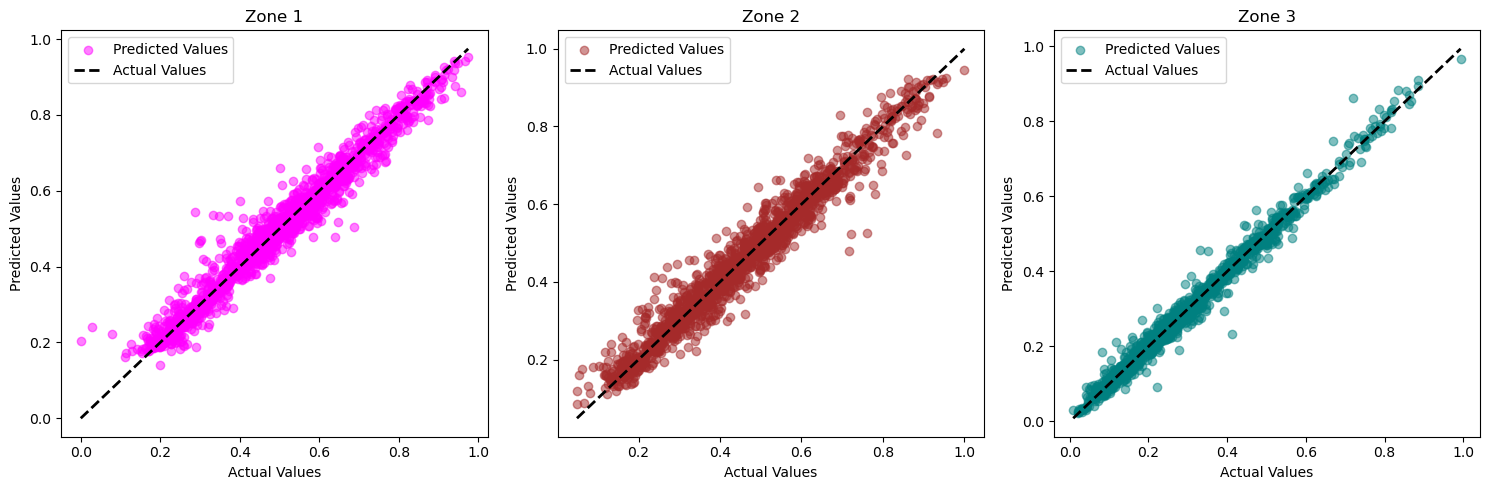

In [111]:
#import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Zone 1
plt.subplot(1, 3, 1)
plt.scatter(y1_test, y1_pred, alpha=0.5, label='Predicted Values', color='magenta')
plt.plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], 'k--', lw=2, label='Actual Values')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Zone 1")
plt.legend()

# Zone 2
plt.subplot(1, 3, 2)
plt.scatter(y2_test, y2_pred, alpha=0.5, label='Predicted Values', color='brown')
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'k--', lw=2, label='Actual Values')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Zone 2")
plt.legend()

# Zone 3
plt.subplot(1, 3, 3)
plt.scatter(y3_test, y3_pred, alpha=0.5, label='Predicted Values', color='teal')
plt.plot([y3_test.min(), y3_test.max()], [y3_test.min(), y3_test.max()], 'k--', lw=2, label='Actual Values')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Zone 3")
plt.legend()

plt.tight_layout()
plt.show()

Train lightgbm Models

In [99]:
!pip install lightgbm
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# Independent variables
X = df_lagged.drop(['PowerConsumption_Zone1_sum', 'PowerConsumption_Zone2_sum', 'PowerConsumption_Zone3_sum'], axis=1)

# Target variables
y1 = df_lagged['PowerConsumption_Zone1_sum']
y2 = df_lagged['PowerConsumption_Zone2_sum']
y3 = df_lagged['PowerConsumption_Zone3_sum']

# Split data into training and test sets
X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=0)
_, _, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=0)
_, _, y3_train, y3_test = train_test_split(X, y3, test_size=0.2, random_state=0)

# Create and train models
model1 = lgb.LGBMRegressor(random_state=0)
model2 = lgb.LGBMRegressor(random_state=0)
model3 = lgb.LGBMRegressor(random_state=0)

model1.fit(X_train, y1_train)
model2.fit(X_train, y2_train)
model3.fit(X_train, y3_train)

# Make predictions
y1_pred = model1.predict(X_test)
y2_pred = model2.predict(X_test)
y3_pred = model3.predict(X_test)

# Evaluate results
print("##################### MSE #####################")
print("Zone 1 MSE:", np.mean((y1_pred - y1_test)**2))
print("Zone 2 MSE:", np.mean((y2_pred - y2_test)**2))
print("Zone 3 MSE:", np.mean((y3_pred - y3_test)**2))

print("##################### MAE #####################")
print("Zone 1 MAE:", mean_absolute_error(y1_test, y1_pred))
print("Zone 2 MAE:", mean_absolute_error(y2_test, y2_pred))
print("Zone 3 MAE:", mean_absolute_error(y3_test, y3_pred))

print("##################### R^2 #####################")
print("Zone 1 R^2:", r2_score(y1_test, y1_pred))
print("Zone 2 R^2:", r2_score(y2_test, y2_pred))
print("Zone 3 R^2:", r2_score(y3_test, y3_pred))

def adjusted_r2_score(y_true, y_pred, n, p):
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    return adj_r2

# Get the number of test and predicted values
n1 = len(y1_test)
n2 = len(y2_test)
n3 = len(y3_test)

# Specify the number of features
p = X.shape[1]  # Updated to use the number of independent variables

# Adjusted R² for Zone 1
adj_r2_zone1 = adjusted_r2_score(y1_test, y1_pred, n1, p)
print("Zone 1 Adjusted R^2:", adj_r2_zone1)

# Adjusted R² for Zone 2
adj_r2_zone2 = adjusted_r2_score(y2_test, y2_pred, n2, p)
print("Zone 2 Adjusted R^2:", adj_r2_zone2)

# Adjusted R² for Zone 3
adj_r2_zone3 = adjusted_r2_score(y3_test, y3_pred, n3, p)
print("Zone 3 Adjusted R^2:", adj_r2_zone3)

# Print Adjusted R²
print("##################### Adjusted R^2 #####################")
print("Zone 1 Adjusted R^2:", adj_r2_zone1)
print("Zone 2 Adjusted R^2:", adj_r2_zone2)
print("Zone 3 Adjusted R^2:", adj_r2_zone3)

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   - -------------------------------------- 0.0/1.4 MB 495.5 kB/s eta 0:00:03
   --- ------------------------------------ 0.1/1.4 MB 1.2 MB/s eta 0:00:02
   ------- -------------------------------- 0.3/1.4 MB 1.8 MB/s eta 0:00:01
   ------------ --------------------------- 0.5/1.4 MB 2.4 MB/s eta 0:00:01
   ----------------- ---------------------- 0.6/1.4 MB 2.6 MB/s eta 0:00:01
   ----------------------- ---------------- 0.9/1.4 MB 3.2 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.4 MB 3.2 MB/s eta 0:00:01
   ----------------------------------- ---- 1.3/1.4 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------  1.4/1.4 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 3.5 MB/s eta 0:00:00
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004019 secon

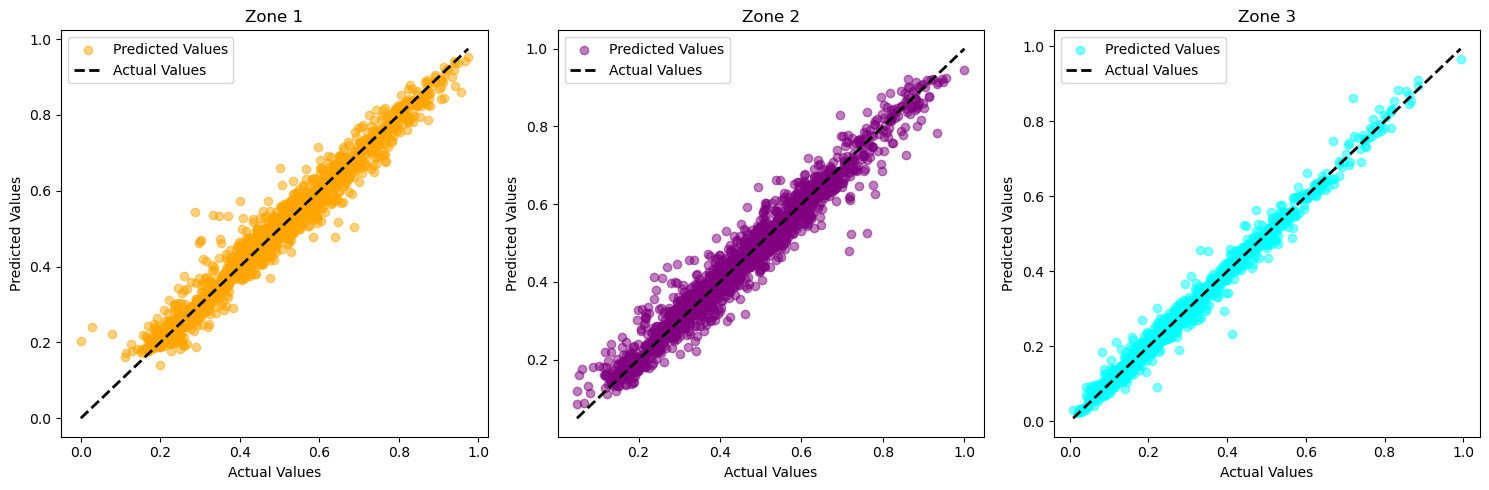

In [109]:
#import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Zone 1
plt.subplot(1, 3, 1)
plt.scatter(y1_test, y1_pred, alpha=0.5, label='Predicted Values', color='orange')
plt.plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], 'k--', lw=2, label='Actual Values')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Zone 1")
plt.legend()

# Zone 2
plt.subplot(1, 3, 2)
plt.scatter(y2_test, y2_pred, alpha=0.5, label='Predicted Values', color='purple')
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'k--', lw=2, label='Actual Values')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Zone 2")
plt.legend()

# Zone 3
plt.subplot(1, 3, 3)
plt.scatter(y3_test, y3_pred, alpha=0.5, label='Predicted Values', color='cyan')
plt.plot([y3_test.min(), y3_test.max()], [y3_test.min(), y3_test.max()], 'k--', lw=2, label='Actual Values')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Zone 3")
plt.legend()

plt.tight_layout()
plt.show()


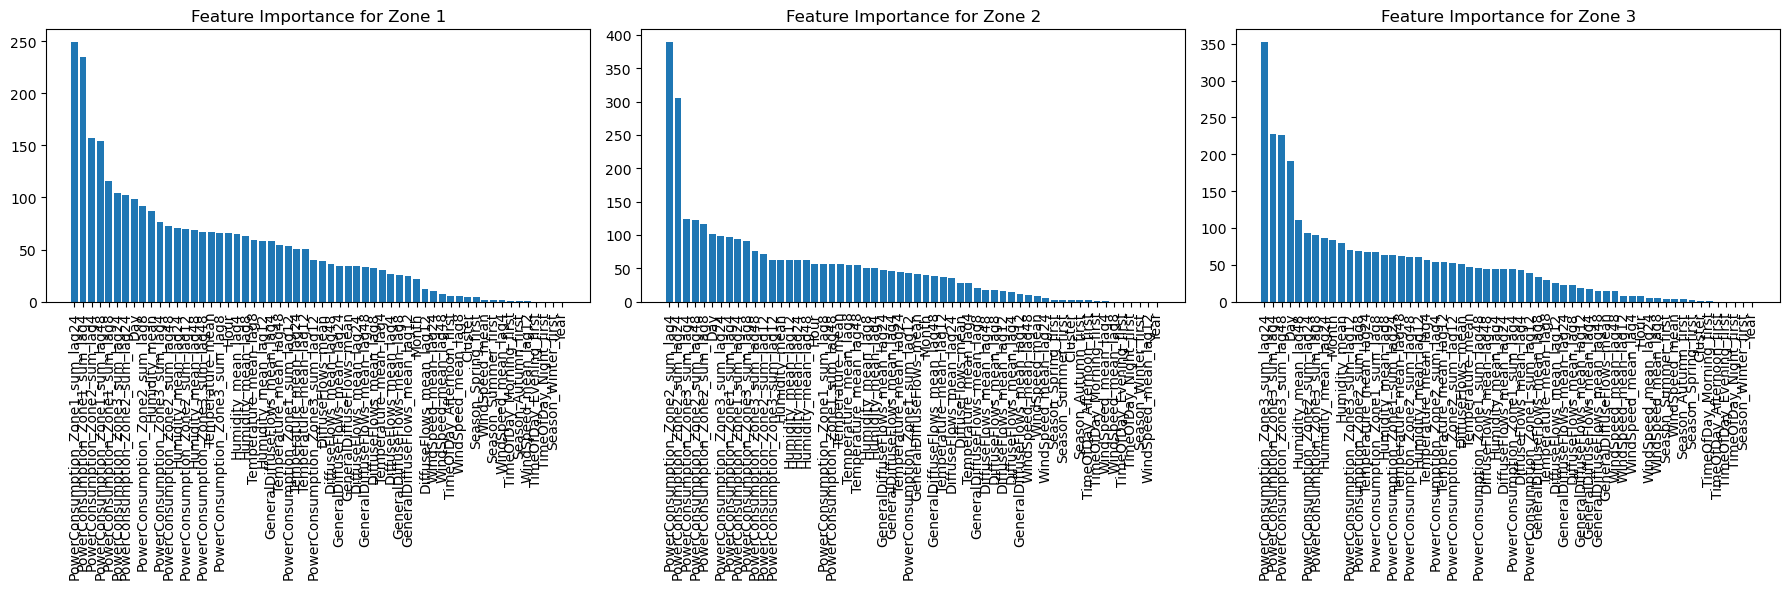

In [107]:
#import matplotlib.pyplot as plt

# Model 1 için feature importance
importances1 = model1.feature_importances_
indices1 = np.argsort(importances1)[::-1]

# Model 2 için feature importance
importances2 = model2.feature_importances_
indices2 = np.argsort(importances2)[::-1]

# Model 3 için feature importance
importances3 = model3.feature_importances_
indices3 = np.argsort(importances3)[::-1]

# Feature isimlerini alma
feature_names = X.columns

# Feature importance değerlerini görselleştirme
plt.figure(figsize=(18, 6))

# Zone 1 için
plt.subplot(1, 3, 1)
plt.title("Feature Importance for Zone 1")
plt.bar(range(X.shape[1]), importances1[indices1], align='center')
plt.xticks(range(X.shape[1]), feature_names[indices1], rotation=90)
plt.tight_layout()

# Zone 2 için
plt.subplot(1, 3, 2)
plt.title("Feature Importance for Zone 2")
plt.bar(range(X.shape[1]), importances2[indices2], align='center')
plt.xticks(range(X.shape[1]), feature_names[indices2], rotation=90)
plt.tight_layout()

# Zone 3 için
plt.subplot(1, 3, 3)
plt.title("Feature Importance for Zone 3")
plt.bar(range(X.shape[1]), importances3[indices3], align='center')
plt.xticks(range(X.shape[1]), feature_names[indices3], rotation=90)
plt.tight_layout()

plt.show()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006346 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9700
[LightGBM] [Info] Number of data points in the train set: 6950, number of used features: 57
[LightGBM] [Info] Start training from score 0.480787
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000883 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9700
[LightGBM] [Info] Number of data points in the train set: 6950, number of used features: 57
[LightGBM] [Info] Start training from score 0.449037
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002257 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9700
[LightGBM] [Info] Number of data points in the train set: 

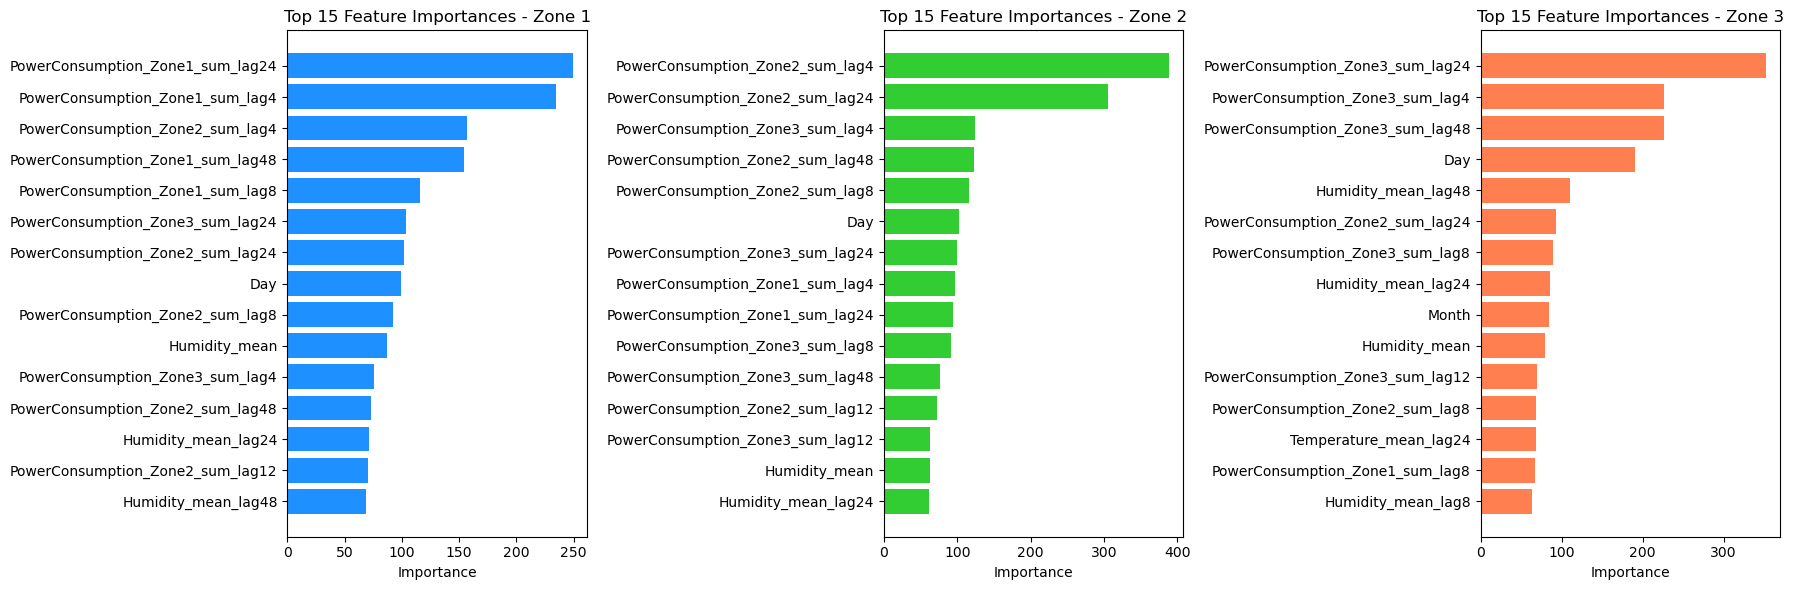

In [105]:
# Independent variables
X = df_lagged.drop(['PowerConsumption_Zone1_sum', 'PowerConsumption_Zone2_sum', 'PowerConsumption_Zone3_sum'], axis=1)

# Target variables
y1 = df_lagged['PowerConsumption_Zone1_sum']
y2 = df_lagged['PowerConsumption_Zone2_sum']
y3 = df_lagged['PowerConsumption_Zone3_sum']

# Split data into training and test sets
X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=0)
_, _, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=0)
_, _, y3_train, y3_test = train_test_split(X, y3, test_size=0.2, random_state=0)

# Create and train models
model1 = lgb.LGBMRegressor(random_state=0)
model2 = lgb.LGBMRegressor(random_state=0)
model3 = lgb.LGBMRegressor(random_state=0)

model1.fit(X_train, y1_train)
model2.fit(X_train, y2_train)
model3.fit(X_train, y3_train)

# Get feature importance values
importances1 = model1.feature_importances_
importances2 = model2.feature_importances_
importances3 = model3.feature_importances_

# Feature names
feature_names = X.columns

# Create DataFrame for feature importances
df_importances1 = pd.DataFrame({'Feature': feature_names, 'Importance': importances1}).sort_values(by='Importance', ascending=False).head(15)
df_importances2 = pd.DataFrame({'Feature': feature_names, 'Importance': importances2}).sort_values(by='Importance', ascending=False).head(15)
df_importances3 = pd.DataFrame({'Feature': feature_names, 'Importance': importances3}).sort_values(by='Importance', ascending=False).head(15)

# Plot the feature importances for each zone
plt.figure(figsize=(18, 6))

# Zone 1
plt.subplot(1, 3, 1)
plt.barh(df_importances1['Feature'], df_importances1['Importance'], color='dodgerblue')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Zone 1')
plt.gca().invert_yaxis()

# Zone 2
plt.subplot(1, 3, 2)
plt.barh(df_importances2['Feature'], df_importances2['Importance'], color='limegreen')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Zone 2')
plt.gca().invert_yaxis()

# Zone 3
plt.subplot(1, 3, 3)
plt.barh(df_importances3['Feature'], df_importances3['Importance'], color='coral')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Zone 3')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()